In [186]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.stats as stats
import pandas as pd

In [187]:
df_disc = pd.read_csv("..\\Data\\2.595.0-Vannføring-inst-v1.csv", parse_dates=True, skiprows = 1, delimiter=";", decimal=",")
df_disc.drop(columns=["Korrigert", "Kontrollert"], inplace=True)
df_disc.dropna(inplace=True)
df_disc.columns = ["date", "Q(m3/s)"]
df_disc.set_index(pd.to_datetime(pd.to_datetime(df_disc["date"]).dt.date), inplace=True)
df_disc.drop(columns=["date"], inplace=True)
df_disc = df_disc.resample("D").mean()

Number of peaks found: 25


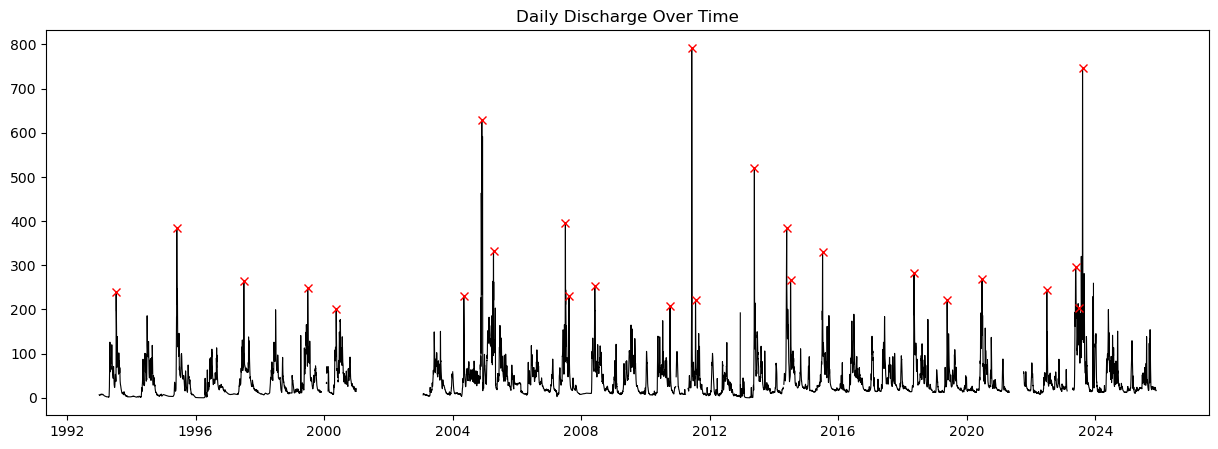

In [188]:
thresh = 200
period = 32

idx, peaks = signal.find_peaks(df_disc["Q(m3/s)"], height=thresh, distance=period)
n = len(peaks["peak_heights"])
n_years = (df_disc.index[-1] - df_disc.index[0]).days / 365.25
avg_peaks = n / n_years
peaks = peaks["peak_heights"]

print("Number of peaks found:", len(peaks))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_disc.index, df_disc["Q(m3/s)"], label="Daily Discharge", color="black", lw=0.8)
ax.plot(df_disc.index[idx], peaks, "x", label="Peaks", color="red", markersize=6)
ax.set_title("Daily Discharge Over Time")

exceedances = peaks - thresh

In [189]:
for dist in [stats.genextreme, stats.gumbel_r, stats.genpareto]:
    params_dist = dist.fit(exceedances)
    dist_name = dist.name
    ks = stats.kstest(exceedances, dist_name, args=params_dist)
    
    print(f"Fitted {dist_name} distribution")
    print(f"K-S test statistic: {ks.statistic}, p-value: {ks.pvalue}")

Fitted genextreme distribution
K-S test statistic: 0.07491117084884069, p-value: 0.9970110941544934
Fitted gumbel_r distribution
K-S test statistic: 0.20219838861063388, p-value: 0.22570646816625284
Fitted genpareto distribution
K-S test statistic: 0.08251960126555141, p-value: 0.9902088868708844


KS Statistic: 0.07491117084884069, p-value: 0.9970110941544934


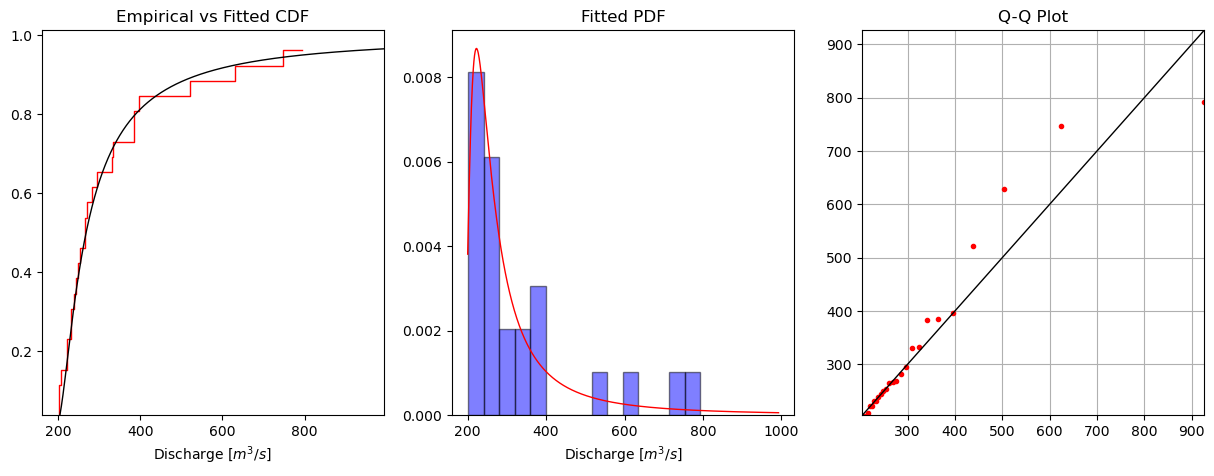

In [199]:
x_ecdf = np.sort(exceedances)
y_ecdf = np.arange(1, n + 1) / (n + 1)

x_pcdf = np.linspace(0, max(df_disc["Q(m3/s)"]), 1000)

distribution = stats.genextreme
params = distribution.fit(exceedances)
pdf = distribution.pdf(x_pcdf, *params)
cdf = distribution.cdf(x_pcdf, *params)

x_qq = distribution.ppf(y_ecdf, *params)
y_qq = x_ecdf

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].step(x_ecdf + thresh, y_ecdf, label="Empirical CDF", lw = 1, color = "red")
ax[0].plot(x_pcdf + thresh, cdf, label="Fitted GEV CDF", color="black", lw = 1)
ax[0].set_title("Empirical vs Fitted CDF")
ax[0].set_xlabel("Discharge [$m^3/s$]")
ax[0].set_ylim(y_ecdf.min())
ax[0].set_xlim(None , x_pcdf.max()+thresh)

ax[1].plot(x_pcdf + thresh, pdf, label="Fitted GEV PDF", color="red", lw = 1)
ax[1].hist(exceedances + thresh, bins=15, density=True, alpha=0.5, label="Empirical PDF", edgecolor = "black", color = "blue")
ax[1].set_title("Fitted PDF")
ax[1].set_xlabel("Discharge [$m^3/s$]")

qq_min = min(x_qq + thresh)
qq_max = max(x_qq + thresh)
ax[2].plot(x_qq + thresh, y_qq + thresh, marker='.', linestyle='none', color = 'red')
ax[2].plot([min(x_qq + thresh), max(x_qq + thresh)], [min(x_qq + thresh), max(x_qq + thresh)], color="black", label="y=x", lw=1)
ax[2].grid()
ax[2].set_title("Q-Q Plot")
ax[2].set_xlim(qq_min, qq_max)
ax[2].set_ylim(qq_min, qq_max)

plt.savefig("../Figures/Discharge_EVA_results.png", dpi=300)

ks_stat, p_value = stats.kstest(exceedances, distribution.name, args=params)
print(f"KS Statistic: {ks_stat}, p-value: {p_value}")

10-year discharge level: 472.40 m^3/s
50-year discharge level: 1169.08 m^3/s
100-year discharge level: 1823.71 m^3/s
200-year discharge level: 2902.02 m^3/s
500-year discharge level: 5468.28 m^3/s


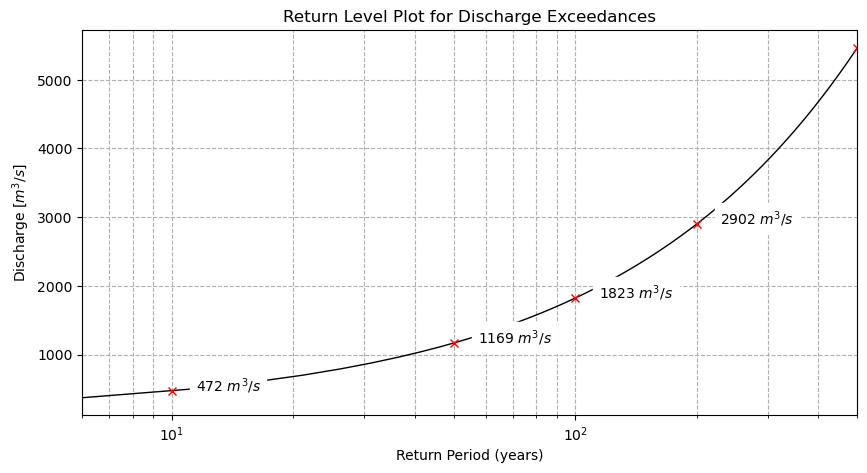

In [200]:
RT = np.linspace(1, 500, 100)
ppf = distribution.ppf(1 - 1 / (RT * avg_peaks), *params) + thresh

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(RT, ppf, label="Return Level Plot", color="black", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Return Period (years)")
ax.set_xlim(6, RT.max())
ax.grid(True, which="both", ls="--")
ax.set_ylabel("Discharge [$m^3/s$]")
ax.set_title("Return Level Plot for Discharge Exceedances")
# ax.set_ylim(thresh, ppf.max() + 50)

for rt in [10, 50, 100, 200, 500]:
    q_rt = distribution.ppf(1 - 1 / (rt * avg_peaks), *params) + thresh
    ax.plot(rt, q_rt, 'x', label=f"{rt}-year level", color = 'red')
    ax.annotate(f"{int(q_rt)} $m^3/s$", xy=(rt * 1.1, q_rt), xytext=(5, 0), textcoords='offset points', backgroundcolor='white')
    rt_vals.append((rt, q_rt))
    print(f"{rt}-year discharge level: {q_rt:.2f} m^3/s")

plt.savefig("../Figures/Discharge_Return_Level_Plot.png", dpi=300)